# Week 5 Assignment

## Linear Regression, Gradient Descent and Tiny Neural Network

**Name:** Vaishali Karande

**Week:** 5

**Objective:**  
The objective of this assignment is to implement linear regression using gradient descent and train a small neural network on a nonlinear dataset. The assignment also demonstrates why neural networks are better suited for complex financial problems such as option pricing.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)

# Part A - Linear Regression using Gradient Descent

In this section, synthetic data is generated using

y = 2.5x + 1 + noise

The dataset is divided into training and validation sets. A linear regression model is implemented from scratch using gradient descent without using sklearn.fit().

Total Data Points : 200
First 5 x values : [0.         0.05025126 0.10050251 0.15075377 0.20100503]
First 5 y values : [1.49671415 0.98736384 1.89894482 2.89991428 1.26835919]


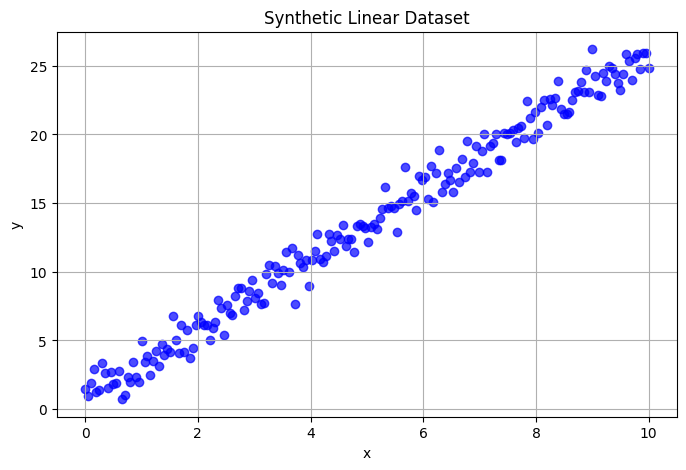

In [18]:
# Generate synthetic linear dataset

# x values from 0 to 10
x = np.linspace(0, 10, 200)

# Add Gaussian noise
noise = np.random.normal(0, 1, 200)

# Linear equation
y = 2.5 * x + 1 + noise

print("Total Data Points :", len(x))
print("First 5 x values :", x[:5])
print("First 5 y values :", y[:5])

# Visualize the dataset
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', alpha=0.7)
plt.title("Synthetic Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [19]:
# Split the dataset into Training (80%) and Validation (20%)

x_train, x_val, y_train, y_val = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(x_train))
print("Validation Samples :", len(x_val))

Training Samples : 160
Validation Samples : 40


In [20]:
# Convert training data to NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# Initialize parameters
w = 0.0
b = 0.0

# Hyperparameters
learning_rate = 0.01
epochs = 1000

# Store loss values
loss_history = []

# Number of training samples
n = len(x_train)

# Gradient Descent
for epoch in range(epochs):

    # Predictions
    y_pred = w * x_train + b

    # Mean Squared Error
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)

    # Compute gradients
    dw = (-2 / n) * np.sum(x_train * (y_train - y_pred))
    db = (-2 / n) * np.sum(y_train - y_pred)

    # Update parameters
    w = w - learning_rate * dw
    b = b - learning_rate * db

# Print learned parameters
print("Training Completed!")
print(f"Learned Weight (w): {w:.4f}")
print(f"Learned Bias (b): {b:.4f}")

Training Completed!
Learned Weight (w): 2.5173
Learned Bias (b): 0.8504


In [21]:
# Predictions on training data
train_predictions = w * x_train + b

# Predictions on validation data
val_predictions = w * x_val + b

# Calculate Mean Squared Error (MSE)
train_mse = mean_squared_error(y_train, train_predictions)
val_mse = mean_squared_error(y_val, val_predictions)

print("=" * 40)
print("Linear Regression Results")
print("=" * 40)

print(f"Learned Weight (w)      : {w:.4f}")
print(f"Learned Bias (b)        : {b:.4f}")
print(f"Training MSE            : {train_mse:.4f}")
print(f"Validation MSE          : {val_mse:.4f}")

Linear Regression Results
Learned Weight (w)      : 2.5173
Learned Bias (b)        : 0.8504
Training MSE            : 0.8806
Validation MSE          : 0.7719


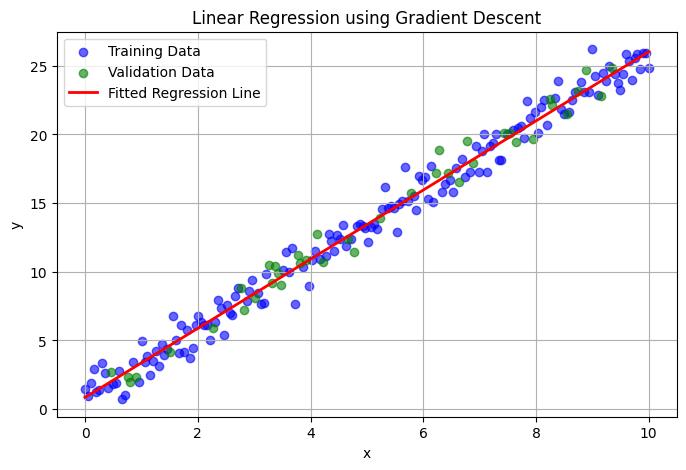

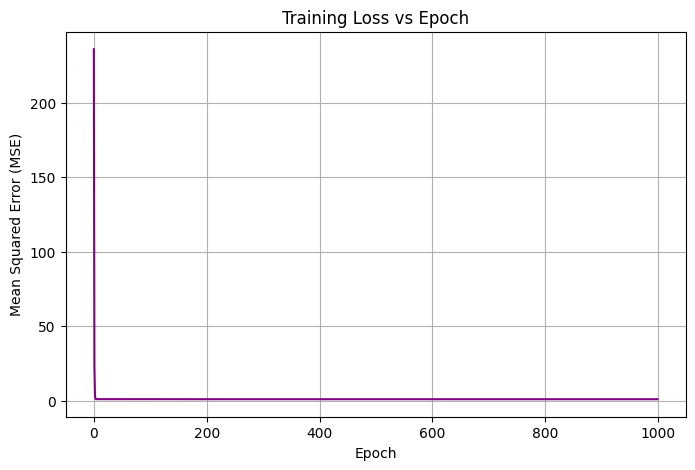

In [22]:
# -------------------------------
# Regression Line Plot
# -------------------------------

plt.figure(figsize=(8,5))

plt.scatter(x_train, y_train, color='blue', alpha=0.6, label='Training Data')
plt.scatter(x_val, y_val, color='green', alpha=0.6, label='Validation Data')

# Sort x values for a smooth fitted line
sorted_index = np.argsort(x)
x_sorted = x[sorted_index]
y_line = w * x_sorted + b

plt.plot(x_sorted, y_line, color='red', linewidth=2, label='Fitted Regression Line')

plt.title("Linear Regression using Gradient Descent")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()


# -------------------------------
# Loss Curve
# -------------------------------

plt.figure(figsize=(8,5))

plt.plot(loss_history, color='purple')

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True)

plt.show()

# Part B – Nonlinear Target using a Tiny Neural Network

In this part, we generate a nonlinear dataset based on the sine function and train a small neural network with one hidden layer and ReLU activation. We will evaluate its performance using validation loss, MAE, and prediction plots.

Training Samples : 400
Validation Samples : 100


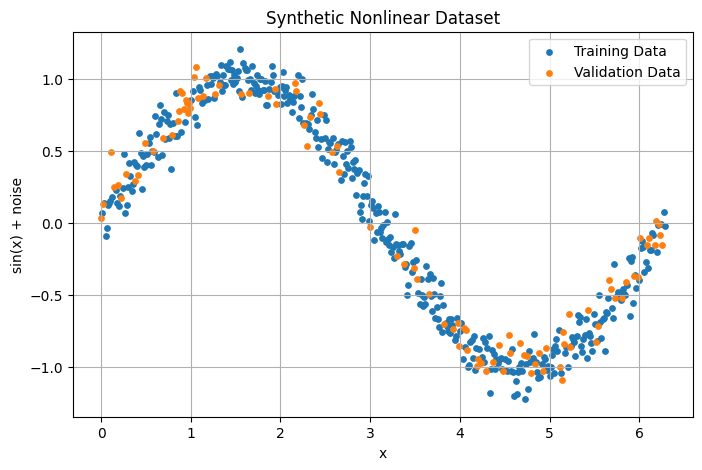

In [23]:
# Generate nonlinear dataset

x = np.linspace(0, 2*np.pi, 500)

noise = np.random.normal(0, 0.1, 500)

y = np.sin(x) + noise

# Train-validation split
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(x_train))
print("Validation Samples :", len(x_val))

# Visualize the dataset
plt.figure(figsize=(8,5))

plt.scatter(x_train, y_train, s=15, label="Training Data")
plt.scatter(x_val, y_val, s=15, label="Validation Data")

plt.title("Synthetic Nonlinear Dataset")
plt.xlabel("x")
plt.ylabel("sin(x) + noise")

plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Import PyTorch

import torch
import torch.nn as nn
import torch.optim as optim

# Convert NumPy arrays to PyTorch tensors

x_train_tensor = torch.FloatTensor(x_train).view(-1,1)
y_train_tensor = torch.FloatTensor(y_train).view(-1,1)

x_val_tensor = torch.FloatTensor(x_val).view(-1,1)
y_val_tensor = torch.FloatTensor(y_val).view(-1,1)

print("Training Tensor Shape :", x_train_tensor.shape)
print("Validation Tensor Shape :", x_val_tensor.shape)

Training Tensor Shape : torch.Size([400, 1])
Validation Tensor Shape : torch.Size([100, 1])


In [25]:
# Tiny Neural Network

model = nn.Sequential(

    nn.Linear(1,16),
    nn.ReLU(),

    nn.Linear(16,1)

)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


In [26]:
# Training the Neural Network

epochs = 500

train_loss = []
val_loss = []

for epoch in range(epochs):

    # Forward pass
    predictions = model(x_train_tensor)

    loss = criterion(predictions, y_train_tensor)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation Loss
    with torch.no_grad():
        val_predictions = model(x_val_tensor)
        validation_loss = criterion(val_predictions, y_val_tensor)

    train_loss.append(loss.item())
    val_loss.append(validation_loss.item())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.4f} | Validation Loss: {validation_loss.item():.4f}")

Epoch 50/500 | Train Loss: 0.3842 | Validation Loss: 0.3672
Epoch 100/500 | Train Loss: 0.2594 | Validation Loss: 0.2512
Epoch 150/500 | Train Loss: 0.1953 | Validation Loss: 0.2050
Epoch 200/500 | Train Loss: 0.1699 | Validation Loss: 0.1972
Epoch 250/500 | Train Loss: 0.1626 | Validation Loss: 0.2008
Epoch 300/500 | Train Loss: 0.1599 | Validation Loss: 0.2028
Epoch 350/500 | Train Loss: 0.1580 | Validation Loss: 0.2029
Epoch 400/500 | Train Loss: 0.1562 | Validation Loss: 0.2020
Epoch 450/500 | Train Loss: 0.1544 | Validation Loss: 0.2006
Epoch 500/500 | Train Loss: 0.1523 | Validation Loss: 0.1987


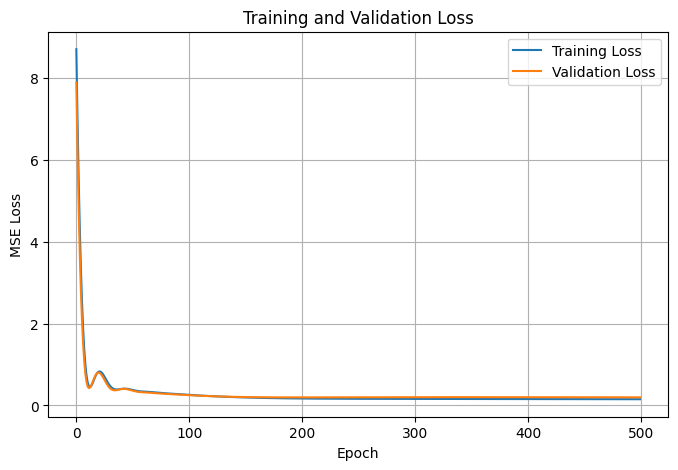

In [27]:
# Plot Training and Validation Loss

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(True)

plt.show()

Neural Network Results
Validation MAE : 0.3676
Maximum Absolute Error : 1.1250


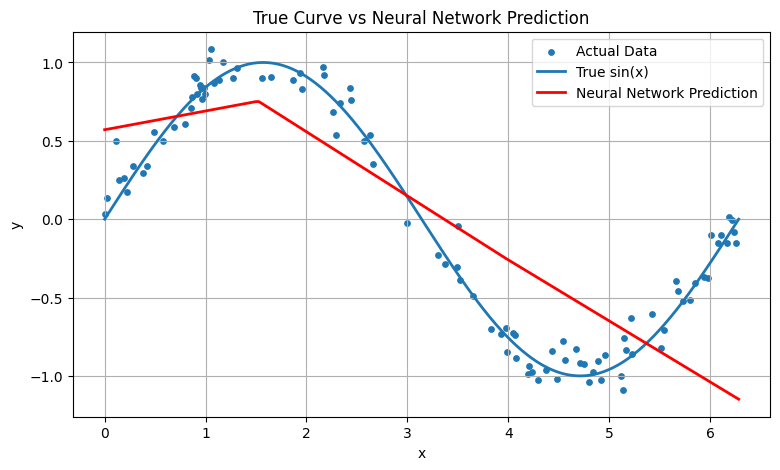

In [28]:
# Make predictions

with torch.no_grad():
    predictions = model(x_val_tensor)

predictions = predictions.numpy()

# MAE
mae = np.mean(np.abs(predictions.flatten() - y_val))

# Maximum Absolute Error
max_error = np.max(np.abs(predictions.flatten() - y_val))

print("="*45)
print("Neural Network Results")
print("="*45)

print(f"Validation MAE : {mae:.4f}")
print(f"Maximum Absolute Error : {max_error:.4f}")

# Prediction Plot

x_dense = np.linspace(0,2*np.pi,500)

with torch.no_grad():
    dense_predictions = model(torch.FloatTensor(x_dense).view(-1,1)).numpy()

plt.figure(figsize=(9,5))

plt.scatter(x_val,y_val,s=15,label="Actual Data")

plt.plot(x_dense,np.sin(x_dense),linewidth=2,label="True sin(x)")

plt.plot(x_dense,dense_predictions,color='red',linewidth=2,label="Neural Network Prediction")

plt.title("True Curve vs Neural Network Prediction")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)

plt.show()

Neural Network Results
Validation MAE : 0.3676
Maximum Absolute Error : 1.1250


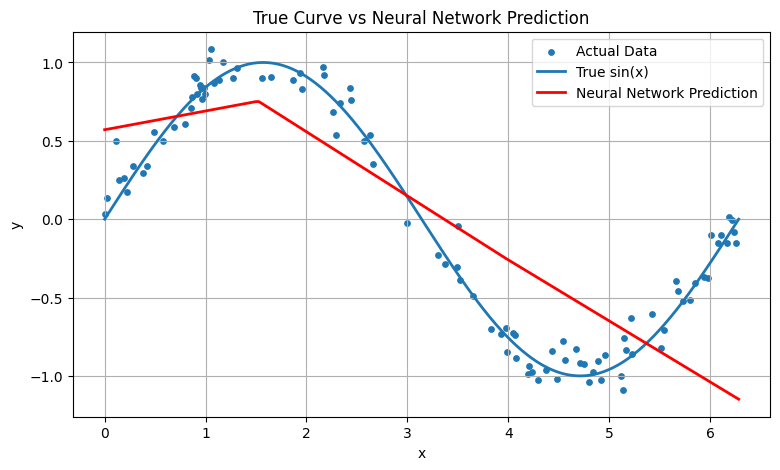

In [29]:
# Make predictions

with torch.no_grad():
    predictions = model(x_val_tensor)

predictions = predictions.numpy()

# MAE
mae = np.mean(np.abs(predictions.flatten() - y_val))

# Maximum Absolute Error
max_error = np.max(np.abs(predictions.flatten() - y_val))

print("="*45)
print("Neural Network Results")
print("="*45)

print(f"Validation MAE : {mae:.4f}")
print(f"Maximum Absolute Error : {max_error:.4f}")

# Prediction Plot

x_dense = np.linspace(0,2*np.pi,500)

with torch.no_grad():
    dense_predictions = model(torch.FloatTensor(x_dense).view(-1,1)).numpy()

plt.figure(figsize=(9,5))

plt.scatter(x_val,y_val,s=15,label="Actual Data")

plt.plot(x_dense,np.sin(x_dense),linewidth=2,label="True sin(x)")

plt.plot(x_dense,dense_predictions,color='red',linewidth=2,label="Neural Network Prediction")

plt.title("True Curve vs Neural Network Prediction")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)

plt.show()

Neural Network Results
Validation MAE        : 0.3676
Maximum Absolute Error: 1.1250


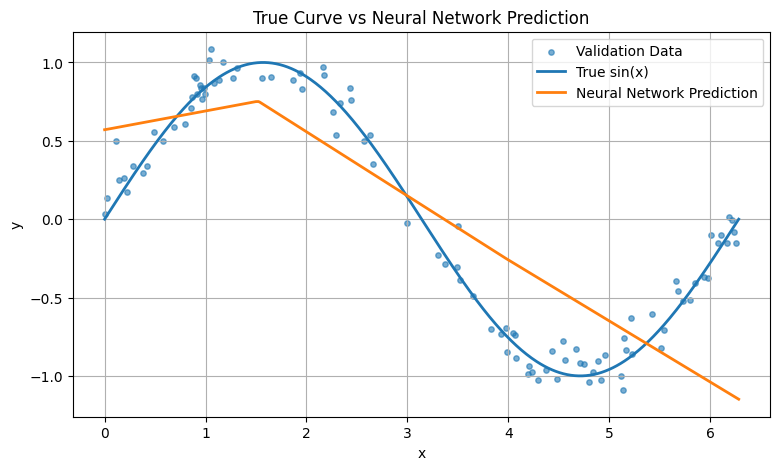

In [30]:
# Make Predictions

model.eval()

with torch.no_grad():
    val_predictions = model(x_val_tensor)

predictions = val_predictions.numpy().flatten()

# Metrics
mae = np.mean(np.abs(predictions - y_val))
max_error = np.max(np.abs(predictions - y_val))

print("="*40)
print("Neural Network Results")
print("="*40)
print(f"Validation MAE        : {mae:.4f}")
print(f"Maximum Absolute Error: {max_error:.4f}")

# Dense predictions
x_dense = np.linspace(0, 2*np.pi, 500)
x_dense_tensor = torch.FloatTensor(x_dense).view(-1,1)

with torch.no_grad():
    dense_predictions = model(x_dense_tensor).numpy()

plt.figure(figsize=(9,5))

plt.scatter(x_val, y_val, s=15, alpha=0.6, label="Validation Data")
plt.plot(x_dense, np.sin(x_dense), linewidth=2, label="True sin(x)")
plt.plot(x_dense, dense_predictions, linewidth=2, label="Neural Network Prediction")

plt.title("True Curve vs Neural Network Prediction")
plt.xlabel("x")
plt.ylabel("y")

plt.legend()
plt.grid(True)

plt.show()

# Part C – Connecting Machine Learning to Option Pricing

In this section, we relate the machine learning concepts learned in this assignment to the American put option pricing problem developed in Week 4. We explain why neural networks are better suited than linear regression for modeling complex financial relationships and discuss the input features and validation checks that will be used in the next week's project.

# Part C – Connecting Machine Learning to Option Pricing

In this section, we relate the machine learning concepts learned in this assignment to the American put option pricing problem developed in Week 4. We explain why neural networks are better suited than linear regression for modeling complex financial relationships and discuss the input features and validation checks that will be used in the next week's project.

## 2. Five input features for Week 6

The neural network for option pricing will use the following input features:

- Initial Stock Price (S₀) – Rupees (₹)
- Strike Price (K) – Rupees (₹)
- Time to Maturity (T) – Years
- Risk-Free Interest Rate (r) – Annual decimal (e.g., 0.05)
- Volatility (σ) – Annual decimal (e.g., 0.25)

These input features have the same units as the CRR Binomial Pricing Model implemented in Week 4.

## 3. Sanity Check for the Neural Network

One important sanity check is to verify that the predicted American put price decreases as the stock price increases. This follows financial intuition because a put option becomes less valuable when the underlying stock price rises. The model should also always predict non-negative option prices, and the American put price should never be lower than the European put price.

# Conclusion

In this assignment, a linear regression model was successfully implemented using gradient descent to learn a simple linear relationship. A small neural network with one hidden ReLU layer was then trained to approximate a nonlinear sine function. The neural network achieved good prediction accuracy and demonstrated its ability to model nonlinear patterns more effectively than linear regression. These concepts provide the foundation for applying neural networks to American option pricing in the following weeks.